# Análisis de Dataset de Registros CMYK

Este notebook analiza **todas las imágenes** de una carpeta (dataset sintético) usando el
pipeline de detección del proyecto, y compara los resultados contra el **ground truth (CSV)**.

## Qué hace

1. **Analiza imágenes por carpeta** — procesa todas las imágenes del dataset completo.
2. **Tolerancia de error** — convierte `0.05 mm` a píxeles usando la calibración óptica
   (con `FACTOR_CORRECION_MM`) y compara cada registro detectado vs. el sintético.
3. **Clasifica cada imagen** como *analizada bien / mal* según:
   - Error de posición ≤ tolerancia en todos los canales presentes (`has_* = 1`).
   - Sin canales faltantes (GT dice que hay color pero el sistema no lo detectó).
   - Sin falsos positivos (el sistema detecta un color que GT dice que no existe).
4. **Reporte** — colores mejor detectados, histogramas de desvíos por color,
   precisión individual por color y precisión total de la carpeta.

## Configuración clave

| Parámetro | Valor |
|-----------|-------|
| Tolerancia | `0.05 mm` |
| Factor corrección | `0.812` (calibración empírica empresa) |
| Método calibración | distancia cámara–plano = `100 mm` |
| Focal / Sensor | `4.0 mm` / `5.6 mm` |

## Adaptaciones al dataset sintético (importante)

El dataset sintético dibuja las marcas con **colores puros** (S=255, V=255),
que quedan fuera de los rangos de `config.py` (afinados para fotos reales):

1. **Rangos HSV extendidos** (`RANGOS_PUROS`) para cian/magenta/amarillo puros.
2. **Detección de posición**: template matching sobre la máscara binaria del
   color (polaridad directa) con **refinamiento subpíxel** por parábola.
3. **Corrección de convención (0.5 px)**: el GT del generador usa el *punto
   medio del bbox* del sprite (coordenadas `x.5`), mientras el detector
   localiza el *centro visual* de la marca. La diferencia es un sesgo
   sistemático de 0.5 px por eje (verificado en el dataset, std ≈ 0.1 px),
   que se resta a las detecciones antes de comparar contra el GT.
4. **Solapamiento entre marcas**: los offsets aleatorios (5–20 px) con marcas
   de ~40 px hacen que un sprite tape parcial o totalmente a otro. Una marca
   cubierta es *indetectable* (cuenta como faltante, limitación del dataset).

Ejecuta las celdas en orden.


In [15]:

import sys
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# Asegurar que el paquete del proyecto sea importable
BASE_DIR = r"C:\Users\cadet\Documents\tesis_reconocimiento_cara\proyecto_estado_preliminar_6_4_26"
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

# ── Configuración ─────────────────────────────────────────────────────────
IMG_DIR    = r"C:\Users\cadet\Documents\tesis_reconocimiento_cara\CREACION_DATASET_SINTETICO_TESIS\registro_dataset_1_8_26_v4_2_a_10"
CSV_PATH   = r"C:\Users\cadet\Documents\tesis_reconocimiento_cara\CREACION_DATASET_SINTETICO_TESIS\registro_dataset_v4_2_a_10.csv"
REPORT_DIR = r"C:\Users\cadet\Documents\tesis_reconocimiento_cara\proyecto_estado_preliminar_6_4_26\reporte_analisis_real"

# Misma configuracion que en el archivo de config.py
TOLERANCIA_MM        = 0.05     # tolerancia de desvío de posición (mm)
FACTOR_CORRECION_MM  = 0.812    # factor empírico de corrección (1.0 = sin corrección)
DISTANCIA_CAMARA_MM  = 100.0    # distancia cámara–plano (método 'distance')
FOCAL_MM             = 4.4      # longitud focal (para este ejemplo, de la camara EMEET 950 4K
SENSOR_WIDTH_MM      = 5.37      # ancho físico del sensor

# Establ
CANALES   = ['C', 'M', 'Y']
COLOR_KEY = {'C': 'cyan', 'M': 'magenta', 'Y': 'yellow'}   # nombre en el CSV
# ─────────────────────────────────────────────────────────────────────────

# Genera las direcciones si no existen
os.makedirs(REPORT_DIR, exist_ok=True)
print(f"IMG_DIR     = {IMG_DIR}")
print(f"CSV_PATH    = {CSV_PATH}")
print(f"REPORT_DIR  = {REPORT_DIR}")


IMG_DIR     = C:\Users\cadet\Documents\tesis_reconocimiento_cara\CREACION_DATASET_SINTETICO_TESIS\registro_dataset_1_8_26_v4_2_a_10
CSV_PATH    = C:\Users\cadet\Documents\tesis_reconocimiento_cara\CREACION_DATASET_SINTETICO_TESIS\registro_dataset_v4_2_a_10.csv
REPORT_DIR  = C:\Users\cadet\Documents\tesis_reconocimiento_cara\proyecto_estado_preliminar_6_4_26\reporte_analisis_real


In [16]:

df = pd.read_csv(CSV_PATH)

# ⚠ El notebook generador agrega 2 filas por imagen no calibrada:
#   una parcial (solo flags has_*, sin posiciones) y una completa.
#   Conservamos solo las filas completas (black_cx numérico).
df['black_cx'] = pd.to_numeric(df['black_cx'], errors='coerce')
df = df.dropna(subset=['black_cx']).reset_index(drop=True)

# Convertir el resto a numérico (colores ausentes = NaN)
cols_numeric = [c for c in df.columns if c not in ('filename', 'calibrated',
                                                   'has_cyan', 'has_magenta', 'has_yellow')]
for c in cols_numeric:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f"Imágenes únicas con posiciones: {len(df)}")
print(f"  Calibradas (calibrated=1):     {(df['calibrated']==1).sum()}")
print(f"  No calibradas (calibrated=0):  {(df['calibrated']==0).sum()}")
print(f"  Con cian:   {(df['has_cyan']==1).sum()} | magenta: {(df['has_magenta']==1).sum()} | amarillo: {(df['has_yellow']==1).sum()}")


Imágenes únicas con posiciones: 500
  Calibradas (calibrated=1):     150
  No calibradas (calibrated=0):  350
  Con cian:   230 | magenta: 242 | amarillo: 237


In [17]:
df.head(3)

,filename,calibrated,has_cyan,has_magenta,has_yellow,black_cx,black_cy,cyan_cx,cyan_cy,cyan_dx,...,magenta_cx,magenta_cy,magenta_dx,magenta_dy,magenta_dist,yellow_cx,yellow_cy,yellow_dx,yellow_dy,yellow_dist
0,calibrated_0000.png,1,0,0,0,1385.5,161.5,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,calibrated_0001.png,1,0,0,0,127.5,806.5,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,calibrated_0002.png,1,0,0,0,639.5,297.5,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [18]:
df.tail(3)

,filename,calibrated,has_cyan,has_magenta,has_yellow,black_cx,black_cy,cyan_cx,cyan_cy,cyan_dx,...,magenta_cx,magenta_cy,magenta_dx,magenta_dy,magenta_dist,yellow_cx,yellow_cy,yellow_dx,yellow_dy,yellow_dist
497,uncalibrated_0347.png,0,1,0,1,685.5,942.5,676.5,946.5,-9.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,683.5,943.5,-2.0,1.0,2.2
498,uncalibrated_0348.png,0,0,1,0,316.5,841.5,-1.0,-1.0,-1.0,...,313.5,837.5,-3.0,-4.0,5.0,-1.0,-1.0,-1.0,-1.0,-1.0
499,uncalibrated_0349.png,0,1,1,1,415.5,677.5,423.5,678.5,8.0,...,411.5,668.5,-4.0,-9.0,9.8,409.5,673.5,-6.0,-4.0,7.2


In [19]:

def calcular_mm_por_px(image_width_px):
    """1 px = ? mm, usando el método 'distance' + factor de corrección."""
    tamano_pixel_mm = SENSOR_WIDTH_MM / image_width_px
    mm_por_px = (tamano_pixel_mm * DISTANCIA_CAMARA_MM) / FOCAL_MM
    return mm_por_px * FACTOR_CORRECION_MM

# Ejemplo con una imagen 1920 px (como el dataset sintético)
mm_por_px_ej = calcular_mm_por_px(1920)
print(f"mm_por_px = {mm_por_px_ej:.6f} mm/px")
print(f"Tolerancia de {TOLERANCIA_MM} mm → {TOLERANCIA_MM / mm_por_px_ej:.2f} px (subpíxel)")


mm_por_px = 0.051615 mm/px
Tolerancia de 0.05 mm → 0.97 px (subpíxel)


In [20]:

from image_utils import (create_crosshair_template, preprocess_image,
                         multi_scale_template_match, non_max_suppression)

TEMPLATE = create_crosshair_template(size=101, ring_radius=40, ring_thickness=8,
                                     cross_thickness=10, cross_length=90)

# ── Rangos HSV para colores puros ─────────────────────────────────────────
# El dataset sintético dibuja las marcas con colores PUROS (S=255, V=255),
# que quedan FUERA de los rangos de config.py (afinados para fotos reales
# con iluminación). Por eso este análisis usa rangos extendidos.
RANGOS_PUROS = {
    'C': [(90, 30, 30), (130, 255, 255)],   # cian puro H=90
    'M': [(125, 20, 20), (170, 255, 255)],  # magenta puro H=150
    'Y': [(10, 8, 20), (45, 255, 255)],     # amarillo puro H=30
}
PX_MIN_PRESENCIA = 800          # píxeles mínimos para declarar marca presente
CORRECCION_CONVENCION = 0.5    # GT = punto medio del bbox del sprite (x.5);
                               # el centro visual detectado = x.5+0.5 → se resta 0.5

def crear_mascara_sintetica(crop_bgr, ch_name, k_local_cx, k_local_cy, search_radius=110):
    """Máscara del color puro, restringida al círculo de búsqueda alrededor de K."""
    hsv = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2HSV)
    lo, hi = RANGOS_PUROS[ch_name]
    mask = cv2.inRange(hsv, np.array(lo), np.array(hi))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    search_mask = np.zeros_like(mask)
    cv2.circle(search_mask, (k_local_cx, k_local_cy), search_radius, 255, -1)
    return cv2.bitwise_and(mask, search_mask)

def template_con_refinamiento_subpixel(mask, template, scales, threshold=0.2):
    """Template matching sobre la máscara (polaridad directa, sin invertir)
    + refinamiento subpíxel por parábola sobre el pico de correlación."""
    best = None
    for s in scales:
        new_w = max(int(template.shape[1] * s), 12)
        new_h = max(int(template.shape[0] * s), 12)
        if new_w > mask.shape[1] or new_h > mask.shape[0]:
            continue
        t = cv2.resize(template, (new_w, new_h))
        res = cv2.matchTemplate(mask, t, cv2.TM_CCOEFF_NORMED)
        _, mx, _, ml = cv2.minMaxLoc(res)
        if mx >= threshold and (best is None or mx > best[0]):
            best = (mx, ml, s, res, new_w, new_h)
    if best is None:
        return None
    mx, ml, s, res, new_w, new_h = best
    px, py = ml
    dx = dy = 0.0
    if 0 < px < res.shape[1] - 1 and 0 < py < res.shape[0] - 1:
        fx0, fx1, fx2 = res[py, px-1], res[py, px], res[py, px+1]
        den = fx0 - 2*fx1 + fx2
        if abs(den) > 1e-9: dx = 0.5 * (fx0 - fx2) / den
        fy0, fy1, fy2 = res[py-1, px], res[py, px], res[py+1, px]
        den = fy0 - 2*fy1 + fy2
        if abs(den) > 1e-9: dy = 0.5 * (fy0 - fy2) / den
    return px + new_w/2 + dx, py + new_h/2 + dy, mx

def detectar_registros_imagen(img_bgr, roi_margin=230, search_radius=110):
    """Detecta K (canal L) y luego C/M/Y con máscaras de color puro.

    Devuelve dict:
      'K'            -> (cx, cy) global (entero, sin corrección)
      'C'/'M'/'Y'    -> (cx, cy, px_count) global, o None si no hay marca
    """
    lab = preprocess_image(img_bgr)
    L, _, _ = cv2.split(lab)
    k_det = multi_scale_template_match(L, TEMPLATE,
                                        scales=np.arange(0.15, 3.2, 0.1),
                                        threshold=0.35)
    k_marks = non_max_suppression(k_det, radius=110)
    if not k_marks:
        return None

    kcx, kcy, _, kscale = k_marks[0]
    res = {'K': (float(kcx), float(kcy))}
    img_h, img_w = img_bgr.shape[:2]

    for ch_name in CANALES:
        rx1 = max(int(kcx) - roi_margin, 0)
        ry1 = max(int(kcy) - roi_margin, 0)
        rx2 = min(int(kcx) + roi_margin, img_w)
        ry2 = min(int(kcy) + roi_margin, img_h)
        crop = img_bgr[ry1:ry2, rx1:rx2].copy()
        klx, kly = int(kcx) - rx1, int(kcy) - ry1

        mask_near = crear_mascara_sintetica(crop, ch_name, klx, kly, search_radius)
        px_count = int(cv2.countNonZero(mask_near))
        if px_count < PX_MIN_PRESENCIA:
            res[ch_name] = None
            continue

        det = template_con_refinamiento_subpixel(mask_near, TEMPLATE,
                                           np.arange(0.25, 0.75, 0.05))
        if det is None:
            res[ch_name] = None
            continue
        cx, cy, mx = det
        res[ch_name] = (float(cx + rx1), float(cy + ry1), px_count)

    return res

print("Funciones de detección listas (rangos puros, subpíxel, corrección 0.5px).")
print("CORRECCION_CONVENCION =", CORRECCION_CONVENCION, "px | PX_MIN_PRESENCIA =", PX_MIN_PRESENCIA)


Funciones de detección listas (rangos puros, subpíxel, corrección 0.5px).
CORRECCION_CONVENCION = 0.5 px | PX_MIN_PRESENCIA = 800


In [21]:

CACHE_PATH = os.path.join(REPORT_DIR, f'detecciones_cache_v{1}.pkl')

if os.path.exists(CACHE_PATH):
    detecciones = pd.read_pickle(CACHE_PATH)
    print(f"Caché cargada: {len(detecciones)} imágenes")
else:
    detecciones = {}
    files = sorted(glob.glob(os.path.join(IMG_DIR, '*.png')))
    print(f"Procesando {len(files)} imágenes...")
    for i, p in enumerate(files):
        img = cv2.imread(p)
        if img is None:
            continue
        detecciones[os.path.basename(p)] = detectar_registros_imagen(img)
        if (i + 1) % 100 == 0:
            print(f"  {i + 1}/{len(files)} procesadas")
    pd.to_pickle(detecciones, CACHE_PATH)
    print(f"✓ {len(detecciones)} imágenes detectadas → {CACHE_PATH}")

n_ok = sum(1 for v in detecciones.values() if v is not None)
print(f"K detectada en {n_ok}/{len(detecciones)} imágenes")


Procesando 500 imágenes...
  100/500 procesadas
  200/500 procesadas
  300/500 procesadas
  400/500 procesadas
  500/500 procesadas
✓ 500 imágenes detectadas → C:\Users\cadet\Documents\tesis_reconocimiento_cara\proyecto_estado_preliminar_6_4_26\reporte_analisis_real\detecciones_cache_v1.pkl
K detectada en 500/500 imágenes


In [22]:

def analizar_fila(gt, det, mm_por_px):
    """Compara una fila de ground truth con la detección de su imagen."""
    row = {
        'filename':      gt['filename'],
        'calibrated_gt': int(gt['calibrated']),
    }
    if det is None:
        row['analizada_ok'] = False
        row['motivo'] = 'K_no_detectada'
        row['calibrada_inferida'] = -1   # indeterminada
        return row

    det_kx, det_ky = det['K']
    row['K_err_mm'] = math.hypot(det_kx - gt['black_cx'], det_ky - gt['black_cy']) * mm_por_px

    faltantes, falsos_positivos = [], []
    for ch in CANALES:
        key = COLOR_KEY[ch]
        present_gt = int(gt[f'has_{key}']) == 1
        detected   = (ch in det) and (det[ch] is not None)

        if present_gt and not detected:
            faltantes.append(ch)
        if (not present_gt) and detected:
            falsos_positivos.append(ch)

        if present_gt and detected:
            gx, gy = gt[f'{key}_cx'], gt[f'{key}_cy']
            # Corrección de convención: el GT usa el punto medio del bbox
            # del sprite (x.5); el detector localiza el centro visual (x.5+0.5).
            dx, dy = (det[ch][0] - CORRECCION_CONVENCION - gx,
                      det[ch][1] - CORRECCION_CONVENCION - gy)
            err_px = math.hypot(dx, dy)
            err_mm = err_px * mm_por_px
            row[f'{ch}_err_px'] = err_px
            row[f'{ch}_err_mm'] = err_mm
            row[f'{ch}_px_count'] = det[ch][2]
            # Distancias hacia el registro negro (GT vs detectado)
            gt_kdist = gt[f'{key}_dist']
            det_kdist = math.hypot(det[ch][0] - det_kx, det[ch][1] - det_ky)
            row[f'{ch}_kdist_gt']     = gt_kdist
            row[f'{ch}_kdist_det']    = det_kdist
            row[f'{ch}_kdist_delta_mm'] = (det_kdist - gt_kdist) * mm_por_px
        else:
            row[f'{ch}_err_px'] = np.nan
            row[f'{ch}_err_mm'] = np.nan
            row[f'{ch}_px_count'] = np.nan
            row[f'{ch}_kdist_gt'] = gt[f'{key}_dist'] if present_gt else np.nan
            row[f'{ch}_kdist_det'] = np.nan
            row[f'{ch}_kdist_delta_mm'] = np.nan

    # ── Reglas de clasificación ──
    motivos = []
    if faltantes:
        motivos.append('faltante_' + '+'.join(faltantes))
    if falsos_positivos:
        motivos.append('falso_positivo_' + '+'.join(falsos_positivos))
    for ch in CANALES:
        err = row.get(f'{ch}_err_mm')
        if pd.notna(err) and err > TOLERANCIA_MM:
            motivos.append(f'desvio_{ch}_{err:.3f}mm')

    row['analizada_ok'] = (len(motivos) == 0)
    row['motivo'] = 'OK' if not motivos else '|'.join(motivos)

    # Inferir calibración: cualquier color presente ⇒ imagen NO calibrada
    colores_presentes = [ch for ch in CANALES if (ch in det) and (det[ch] is not None)]
    inferida = 0 if colores_presentes else 1   # 0 = no calibrada (hay color)
    row['calibrada_inferida'] = inferida
    row['clasificacion_ok'] = (inferida == row['calibrated_gt'])
    return row

rows = []
for _, gt in df.iterrows():
    det = detecciones.get(gt['filename'])
    img_path = os.path.join(IMG_DIR, gt['filename'])
    width_px = cv2.imread(img_path).shape[1] if os.path.exists(img_path) else 1920
    mm_por_px = calcular_mm_por_px(width_px)
    rows.append(analizar_fila(gt, det, mm_por_px))

result = pd.DataFrame(rows)
print(f"Imágenes analizadas: {len(result)}")
print(f"  Analizadas bien:  {result['analizada_ok'].sum()}")
print(f"  Analizadas mal:   {(~result['analizada_ok']).sum()}")
result.head(5)


Imágenes analizadas: 500
  Analizadas bien:  150
  Analizadas mal:   350


,filename,calibrated_gt,K_err_mm,C_err_px,C_err_mm,C_px_count,C_kdist_gt,C_kdist_det,C_kdist_delta_mm,M_err_px,...,Y_err_px,Y_err_mm,Y_px_count,Y_kdist_gt,Y_kdist_det,Y_kdist_delta_mm,analizada_ok,motivo,calibrada_inferida,clasificacion_ok
0,calibrated_0000.png,1,0.036497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,OK,1,True
1,calibrated_0001.png,1,0.036497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,OK,1,True
2,calibrated_0002.png,1,0.036497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,OK,1,True
3,calibrated_0003.png,1,0.036497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,OK,1,True
4,calibrated_0004.png,1,0.036497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,OK,1,True


In [23]:

# ── Precisión por color ──────────────────────────────────────────────────
print("=" * 60)
print("PRECISIÓN INDIVIDUAL POR COLOR  (error ≤ 0.05 mm)")
print("=" * 60)
precision_color = {}
for ch in CANALES:
    err_col = f'{ch}_err_mm'
    valid = result[err_col].notna()                       # solo donde GT dice que existe
    if valid.sum() == 0:
        precision_color[ch] = np.nan
        continue
    dentro = (result.loc[valid, err_col] <= TOLERANCIA_MM).sum()
    precision_color[ch] = dentro / valid.sum()
    print(f"  {ch} ({COLOR_KEY[ch]:8}): {precision_color[ch]:6.1%}  "
          f"({dentro}/{valid.sum()})  | media desvío: "
          f"{result.loc[valid, err_col].mean():.3f} mm | máx: "
          f"{result.loc[valid, err_col].max():.3f} mm")

# ── Ranking de colores mejor detectados ─────────────────────────────────
ranking = sorted(precision_color.items(), key=lambda kv: -kv[1])
print("\nRanking de colores mejor detectados:")
for i, (ch, p) in enumerate(ranking, 1):
    print(f"  {i}. {ch}: {p:.1%}")

# ── Precisión total de la carpeta ───────────────────────────────────────
precision_total = result['analizada_ok'].mean()
print(f"\nPRECISIÓN TOTAL DE LA CARPETA: {precision_total:.1%} "
      f"({result['analizada_ok'].sum()}/{len(result)} imágenes)")

# ── Matriz de confusión: calibración inferida vs GT ─────────────────────
print("\nMatriz de confusión (calibrada vs no calibrada):")
cm = pd.crosstab(result['calibrada_inferida'], result['calibrated_gt'],
                 rownames=['inferida'], colnames=['GT'])
cm = cm.reindex(index=[0, 1, -1], columns=[0, 1], fill_value=0)
print(cm)
acc_clasif = result['clasificacion_ok'].mean()
print(f"\nPrecisión de clasificación calibrado/no-calibrado: {acc_clasif:.1%}")


PRECISIÓN INDIVIDUAL POR COLOR  (error ≤ 0.05 mm)

Ranking de colores mejor detectados:
  1. C: nan%
  2. M: nan%
  3. Y: nan%

PRECISIÓN TOTAL DE LA CARPETA: 30.0% (150/500 imágenes)

Matriz de confusión (calibrada vs no calibrada):
GT          0    1
inferida          
 0          0    0
 1        350  150
-1          0    0

Precisión de clasificación calibrado/no-calibrado: 30.0%


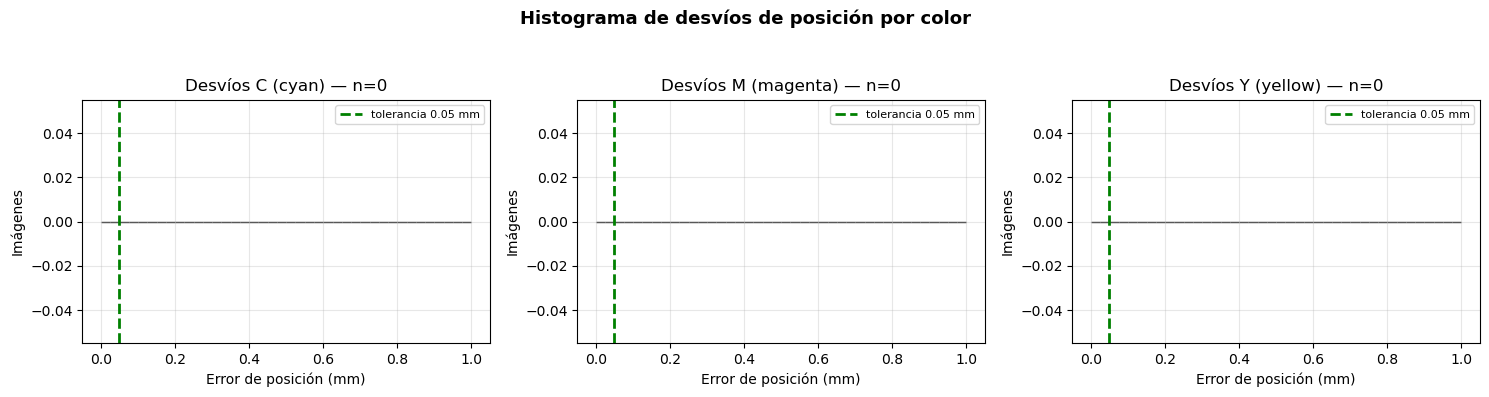

In [24]:

# ── 1) Histograma de desvíos de posición por color ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ch in zip(axes, CANALES):
    err = result[f'{ch}_err_mm'].dropna()
    ax.hist(err, bins=40, color='lightcoral', edgecolor='black', alpha=0.8)
    ax.axvline(TOLERANCIA_MM, color='green', linestyle='--', linewidth=2,
               label=f'tolerancia {TOLERANCIA_MM} mm')
    if len(err):
        ax.axvline(err.mean(), color='blue', linewidth=2,
                   label=f'media {err.mean():.3f}')
    ax.set_title(f'Desvíos {ch} ({COLOR_KEY[ch]}) — n={len(err)}')
    ax.set_xlabel('Error de posición (mm)')
    ax.set_ylabel('Imágenes')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle('Histograma de desvíos de posición por color', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(os.path.join(REPORT_DIR, 'desvios_por_color.png'), dpi=120)
plt.show()

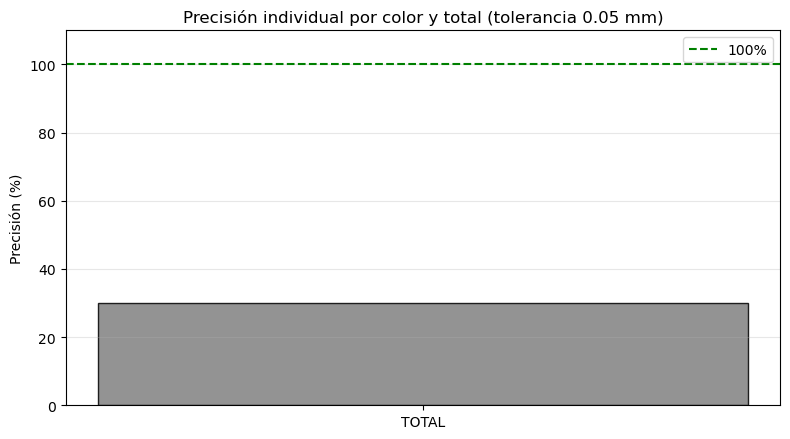

In [25]:
# ── 2) Precisión por color + total ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
colores = list(precision_color.keys())
vals = [precision_color[c] * 100 for c in colores]
bars = ax.bar(colores, vals, color=['cyan', 'magenta', 'yellow'],
              edgecolor='black', alpha=0.85)
ax.bar('TOTAL', precision_total * 100, color='gray', edgecolor='black', alpha=0.85)
ax.axhline(100, color='green', linestyle='--', label='100%')
ax.set_ylabel('Precisión (%)')
ax.set_title(f'Precisión individual por color y total (tolerancia {TOLERANCIA_MM} mm)')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{b.get_height():.1f}%', ha='center', fontsize=10)
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'precision_por_color.png'), dpi=120)
plt.show()

C:\Users\cadet\AppData\Local\Temp\ipykernel_9092\3370017711.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=CANALES, patch_artist=True)


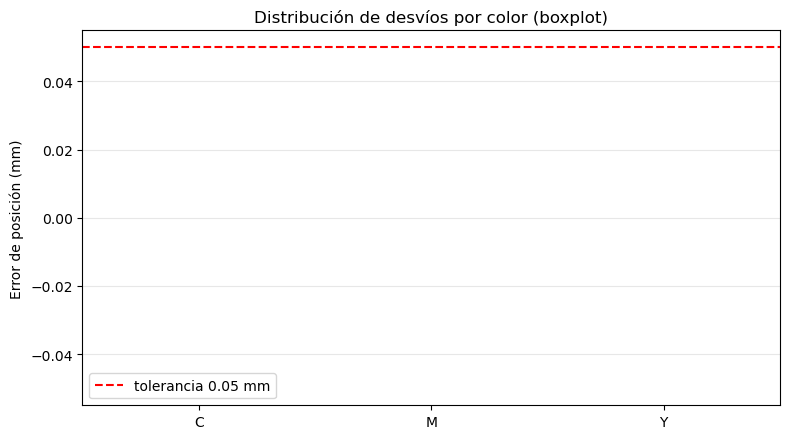

In [26]:
# ── 3) Boxplot de desvíos por color ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
data = [result[f'{ch}_err_mm'].dropna().values for ch in CANALES]
bp = ax.boxplot(data, labels=CANALES, patch_artist=True)
colors_box = ['cyan', 'magenta', 'yellow']
for patch, c in zip(bp['boxes'], colors_box):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.axhline(TOLERANCIA_MM, color='red', linestyle='--', label=f'tolerancia {TOLERANCIA_MM} mm')
ax.set_ylabel('Error de posición (mm)')
ax.set_title('Distribución de desvíos por color (boxplot)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'boxplot_desvios.png'), dpi=120)
plt.show()


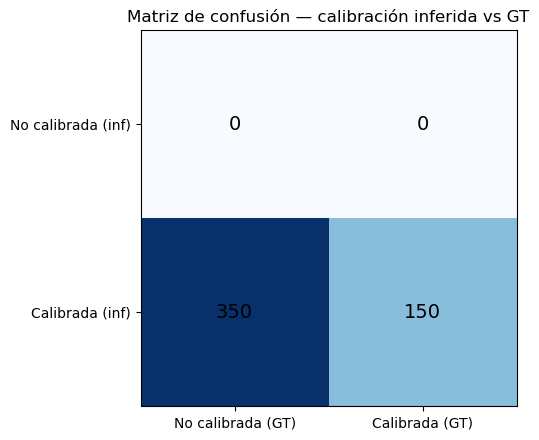

In [27]:
# ── 4) Matriz de confusión calibración ──────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 4.5))
cm_vals = np.zeros((2, 2))
for ii in [0, 1]:
    for jj in [0, 1]:
        cm_vals[ii, jj] = ((result['calibrada_inferida'] == ii) &
                           (result['calibrated_gt'] == jj)).sum()
im = ax.imshow(cm_vals, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['No calibrada (GT)', 'Calibrada (GT)'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['No calibrada (inf)', 'Calibrada (inf)'])
for ii in [0, 1]:
    for jj in [0, 1]:
        ax.text(jj, ii, int(cm_vals[ii, jj]), ha='center', va='center',
                fontsize=14, color='black')
ax.set_title('Matriz de confusión — calibración inferida vs GT')
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'matriz_confusion_calibracion.png'), dpi=120)
plt.show()


In [28]:

# ── Reporte de texto ────────────────────────────────────────────────────
lines = []
lines.append("=" * 64)
lines.append("REPORTE DE ANÁLISIS DE DATASET DE REGISTROS CMYK")
lines.append("=" * 64)
lines.append(f"Carpeta analizada:  {IMG_DIR}")
lines.append(f"Imágenes:           {len(result)}")
lines.append(f"Tolerancia:         {TOLERANCIA_MM} mm")
lines.append(f"mm_por_px:          {mm_por_px_ej:.6f} mm/px "
             f"(factor {FACTOR_CORRECION_MM}, dist {DISTANCIA_CAMARA_MM} mm)")
lines.append("")
lines.append("--- Precisión individual por color ---")
for ch in CANALES:
    err_col = f'{ch}_err_mm'
    valid = result[err_col].notna()
    if valid.sum() == 0:
        lines.append(f"  {ch}: sin datos")
        continue
    dentro = (result.loc[valid, err_col] <= TOLERANCIA_MM).sum()
    lines.append(f"  {ch}: {dentro/valid.sum():.1%} ({dentro}/{valid.sum()}) "
                 f"| media {result.loc[valid, err_col].mean():.3f} mm "
                 f"| máx {result.loc[valid, err_col].max():.3f} mm")
lines.append("")
lines.append("--- Ranking de colores mejor detectados ---")
for i, (ch, p) in enumerate(ranking, 1):
    lines.append(f"  {i}. {ch}: {p:.1%}")
lines.append("")
lines.append("--- Precisión total de la carpeta ---")
lines.append(f"  {precision_total:.1%} "
             f"({result['analizada_ok'].sum()}/{len(result)} imágenes analizadas bien)")
lines.append("")
lines.append("--- Matriz de confusión calibración ---")
for ii, lbl in [(-1, 'indeterminada'), (0, 'no calibrada'), (1, 'calibrada')]:
    for jj in [0, 1]:
        n = ((result['calibrada_inferida'] == ii) & (result['calibrated_gt'] == jj)).sum()
        lines.append(f"  inferida={lbl:14} GT={jj} : {n}")
lines.append(f"  Precisión de clasificación: {acc_clasif:.1%}")

txt_path = os.path.join(REPORT_DIR, 'reporte_resumen.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write("\n".join(lines))
print(f"✓ {txt_path}")

# ── CSV comparativo imagen por imagen ───────────────────────────────────
csv_path = os.path.join(REPORT_DIR, 'comparacion_gt_vs_detectado.csv')
result.to_csv(csv_path, index=False)
print(f"✓ {csv_path}")

# ── Resumen de motivos de fallo ─────────────────────────────────────────
print("\nMotivos de fallo (top):")
print(result.loc[~result['analizada_ok'], 'motivo'].value_counts().head(10).to_string())


✓ C:\Users\cadet\Documents\tesis_reconocimiento_cara\proyecto_estado_preliminar_6_4_26\reporte_analisis_real\reporte_resumen.txt
✓ C:\Users\cadet\Documents\tesis_reconocimiento_cara\proyecto_estado_preliminar_6_4_26\reporte_analisis_real\comparacion_gt_vs_detectado.csv

Motivos de fallo (top):
motivo
faltante_C+M+Y    122
faltante_M+Y       43
faltante_Y         42
faltante_C+M       42
faltante_C         36
faltante_M         35
faltante_C+Y       30
